# EDA and Report Figures Notebook

**Purpose:**  
This notebook performs exploratory data analysis (EDA) for the final 1,000-player youth chess modelling dataset and creates the figures/tables used in the report appendix.

**Main outputs:**  
- Univariate charts for sample composition and activity  
- Bivariate charts linking predictors to 12-month rating gain  
- Correlation heatmap and EDA summaries  
- Report-ready figures used in Appendix B


#### Use the base tables
1. player_sample              # 1,000-player player-level FIDE sample
2. fide_calc_all_players      # opponent-level FIDE calculation-page data, 24,204 rows


In [3]:
# ============================================================
# Import required libraries
# Purpose:
# - Load libraries for data handling, numerical analysis, and visualization.
# ============================================================


## 1. Setup, imports, and path configuration

This section loads required libraries and defines paths for reading the final modelling dataset and saving any EDA outputs.


In [5]:
# ============================================================
# Define input and output paths
# Purpose:
# - Set the path to the final player-level modelling dataset.
# - Set folders for saving EDA figures or tables if used.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.errors import EmptyDataError

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 100)

#### 1. Read your 1,000-player sample

In [7]:
# ============================================================
# Inspect data shape and columns
# Purpose:
# - Confirm row count, column names, and basic structure before EDA.
# ============================================================
player_sample_1000_output_path = (
    Path.home() / "Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess" / "data" / "processed" / "player_sample_1000.csv"
)

player_sample = pd.read_csv(player_sample_1000_output_path)

player_sample.columns = player_sample.columns.str.strip()
player_sample["ID Number"] = player_sample["ID Number"].astype(str).str.strip()

print("player_sample shape:", player_sample.shape)
display(player_sample.head())
print(player_sample.columns.tolist())

player_sample shape: (1000, 17)


,ID Number,Name,Fed,Sex,Title,Birth_Year,rating_start,rating_end,months_available,total_games_12m,avg_monthly_games,max_monthly_games,active_months_12m,inactive_months_12m,rating_gain_12m,age_approx_2026,rating_band
0,558016627,Jivtesh Tuli,IND,M,NaN,2011.0,1522,1502,3,8,2.666667,8,1,2,-20,15.0,1400-1599
1,531075452,Shukla Rajvi Mahesh,IND,F,NaN,2013.0,1606,1562,6,11,1.833333,11,1,5,-44,13.0,1600-1799
2,537082728,Bishan Das,IND,M,NaN,2012.0,1449,1449,1,8,8.000000,8,1,0,0,14.0,1400-1599
3,25789783,Raman Siddhardh B,IND,M,NaN,2011.0,1847,1705,12,62,5.166667,19,6,6,-142,15.0,1800-1999
4,45056404,Sradha Suman Jena,IND,F,NaN,2008.0,1482,1482,12,0,0.000000,0,0,12,0,18.0,1400-1599


['ID Number', 'Name', 'Fed', 'Sex', 'Title', 'Birth_Year', 'rating_start', 'rating_end', 'months_available', 'total_games_12m', 'avg_monthly_games', 'max_monthly_games', 'active_months_12m', 'inactive_months_12m', 'rating_gain_12m', 'age_approx_2026', 'rating_band']


## 2. Load final modelling dataset

This section reads the player-level modelling dataset used for EDA. The dataset should match the frozen 1,000-player sample used in the report.


#### 2. Read the combined FIDE calculation-page opponent data

Use the file name saved.

In [10]:
# ============================================================
# Prepare rating bands or categorical groups
# Purpose:
# - Create or verify grouped variables used in report charts.
# ============================================================

calc_path=Path.home() / "Downloads" / "fide_history" / "fide_calculations_all_players_standard_clean_combined.csv"

fide_calc_all_players = pd.read_csv(calc_path)

fide_calc_all_players.columns = fide_calc_all_players.columns.str.strip()
fide_calc_all_players["fide_id"] = fide_calc_all_players["fide_id"].astype(str).str.strip()

print("Using calculation file:", calc_path)
print("fide_calc_all_players shape:", fide_calc_all_players.shape)
display(fide_calc_all_players.head())
print(fide_calc_all_players.columns.tolist())

Using calculation file: /Users/arunkumar/Downloads/fide_history/fide_calculations_all_players_standard_clean_combined.csv
fide_calc_all_players shape: (24204, 24)


,fide_id,period,rating_type,tournament_name,event_location_fed,event_start_date,event_end_date,event_rc,event_ro,event_score,event_games,event_chg,event_k,event_k_chg,opponent_name,opponent_title,opponent_rating,rating_difference_over_400_flag,opponent_fed,score,n,chg,k,k_chg
0,14350670,2024-05-01,0,Tamil Nadu State Women Chess Championship 2024,Kovilpatti IND,2024-04-24,2024-04-28,1577.0,1426.0,1.0,4,-0.21,40,-8.4,"Ananya, Manisundaram",NaN,1621.0,False,IND,0.0,1,-0.25,40.0,-10.0
1,14350670,2024-05-01,0,Tamil Nadu State Women Chess Championship 2024,Kovilpatti IND,2024-04-24,2024-04-28,1577.0,1426.0,1.0,4,-0.21,40,-8.4,"Lakshanaa, R",NaN,1633.0,False,IND,0.0,1,-0.23,40.0,-9.2
2,14350670,2024-05-01,0,Tamil Nadu State Women Chess Championship 2024,Kovilpatti IND,2024-04-24,2024-04-28,1577.0,1426.0,1.0,4,-0.21,40,-8.4,"Sandhana, D",NaN,1531.0,False,IND,0.0,1,-0.36,40.0,-14.4
3,14350670,2024-05-01,0,Tamil Nadu State Women Chess Championship 2024,Kovilpatti IND,2024-04-24,2024-04-28,1577.0,1426.0,1.0,4,-0.21,40,-8.4,"Rithika, M",NaN,1522.0,False,IND,1.0,1,0.63,40.0,25.2
4,14350670,2024-06-01,0,Tamil Nadu State Under 17 Girls FIDE Rated Chess Championship-2024,Arupukottai IND,2024-05-01,2024-05-05,1530.0,1418.0,2.0,6,-0.20,40,-8.0,"Shanmathi, Sree S",NaN,1818.0,True,IND,0.0,1,-0.08,40.0,-3.2


['fide_id', 'period', 'rating_type', 'tournament_name', 'event_location_fed', 'event_start_date', 'event_end_date', 'event_rc', 'event_ro', 'event_score', 'event_games', 'event_chg', 'event_k', 'event_k_chg', 'opponent_name', 'opponent_title', 'opponent_rating', 'rating_difference_over_400_flag', 'opponent_fed', 'score', 'n', 'chg', 'k', 'k_chg']


#### 3. Basic checks after reading

## 3. Inspect dataset structure and missing values

This section checks dimensions, column names, data types, and missing-value patterns before plotting.


In [13]:
# ============================================================
# Plot gender distribution
# Purpose:
# - Show gender composition of the sample.
# - Supports cautious interpretation of gender subgroup results.
# ============================================================

print("Sample players:", player_sample["ID Number"].nunique())
print("Players with opponent data:", fide_calc_all_players["fide_id"].nunique())
print("Opponent-game rows:", len(fide_calc_all_players))
print("Unique tournaments:", fide_calc_all_players["tournament_name"].nunique())

Sample players: 1000
Players with opponent data: 629
Opponent-game rows: 24204
Unique tournaments: 368


#### 4. Convert dates and numeric fields

In [15]:
# ============================================================
# Plot games played distribution
# Purpose:
# - Show activity intensity over the feature window.
# - Supports inclusion of total_games_12m as a core predictor.
# ============================================================

calc_df = fide_calc_all_players.copy()

calc_df["period"] = pd.to_datetime(calc_df["period"], errors="coerce")
calc_df["event_start_date"] = pd.to_datetime(calc_df["event_start_date"], errors="coerce")
calc_df["event_end_date"] = pd.to_datetime(calc_df["event_end_date"], errors="coerce")

numeric_calc_cols = [
    "event_rc", "event_ro", "event_score", "event_games",
    "event_chg", "event_k", "event_k_chg",
    "opponent_rating", "score", "n", "chg", "k", "k_chg"
]

for col in numeric_calc_cols:
    if col in calc_df.columns:
        calc_df[col] = pd.to_numeric(calc_df[col], errors="coerce")

print("Period range:", calc_df["period"].min(), "to", calc_df["period"].max())

Period range: 2024-05-01 00:00:00 to 2025-04-01 00:00:00


## 4. Univariate analysis of key variables

This section examines one variable at a time, including rating band, gender, title status, games played, active months, calculation-page availability, and rating gain.


#### 5. Confirm sample-vs-calculation coverage

In [18]:
# ============================================================
# Plot calculation-page availability
# Purpose:
# - Show how many players have usable FIDE calculation-page data.
# - Supports separate baseline and enriched modelling datasets.
# ============================================================

sample_ids = set(player_sample["ID Number"].astype(str).str.strip())
calc_ids = set(calc_df["fide_id"].astype(str).str.strip())

print("Sample players:", len(sample_ids))
print("Players with calculation data:", len(calc_ids))
print("Calculation players not in sample:", len(calc_ids - sample_ids))
print("Sample players without calculation data:", len(sample_ids - calc_ids))

Sample players: 1000
Players with calculation data: 629
Calculation players not in sample: 0
Sample players without calculation data: 371


##### Now, the EDA notebook will have the same working DataFrames:
* player_sample
* calc_df
* fide_calc_all_players

In [20]:
# ============================================================
# Bivariate plot - rating at cutoff vs future gain
# Purpose:
# - Check whether current rating alone explains future rating improvement.
# ============================================================

#### Data availability and basic checks

In [21]:
# ============================================================
# Bivariate plot - games played vs future gain
# Purpose:
# - Explore relationship between activity intensity and 12-month rating gain.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 100)

## 5. Bivariate analysis and feature-outcome relationships

This section studies how predictors such as starting rating, games played, active months, opponent rating, and score percentage relate to future rating gain.


In [23]:
# ============================================================
# Bivariate plot - active months vs future gain
# Purpose:
# - Explore whether participation consistency is related to future gain.
# ============================================================

print("player_sample shape:", player_sample.shape)
print("calc_df shape:", calc_df.shape)

print("\nUnique players in sample:", player_sample["ID Number"].nunique())
print("Unique players with calculation data:", calc_df["fide_id"].nunique())
print("Opponent-game rows:", calc_df.shape[0])
print("Unique tournaments:", calc_df["tournament_name"].nunique())
print("Calculation period range:", calc_df["period"].min(), "to", calc_df["period"].max())

player_sample shape: (1000, 17)
calc_df shape: (24204, 24)

Unique players in sample: 1000
Unique players with calculation data: 629
Opponent-game rows: 24204
Unique tournaments: 368
Calculation period range: 2024-05-01 00:00:00 to 2025-04-01 00:00:00


In [24]:
# ============================================================
# Bivariate plot - opponent rating vs future gain
# Purpose:
# - Explore whether stronger-opposition exposure relates to future gain.
# ============================================================

sample_ids = set(player_sample["ID Number"].astype(str).str.strip())
calc_ids = set(calc_df["fide_id"].astype(str).str.strip())

coverage_summary = pd.DataFrame({
    "Metric": [
        "Sample players",
        "Players with calculation data",
        "Players without calculation data",
        "Opponent-game records",
        "Unique tournaments"
    ],
    "Value": [
        len(sample_ids),
        len(calc_ids),
        len(sample_ids - calc_ids),
        calc_df.shape[0],
        calc_df["tournament_name"].nunique()
    ]
})

display(coverage_summary)

,Metric,Value
0,Sample players,1000
1,Players with calculation data,629
2,Players without calculation data,371
3,Opponent-game records,24204
4,Unique tournaments,368


In [25]:
# ============================================================
# Bivariate plot - score percentage vs future gain
# Purpose:
# - Explore whether performance quality in extracted games relates to future gain.
# ============================================================

#EDA Step 2: Check columns in player sample

#Run this to know exact column names before plotting.

In [26]:
# ============================================================
# Stronger-opposition exposure by rating band
# Purpose:
# - Show how exposure to 2000+ opponents varies by player rating band.
# ============================================================

print(player_sample.columns.tolist())

['ID Number', 'Name', 'Fed', 'Sex', 'Title', 'Birth_Year', 'rating_start', 'rating_end', 'months_available', 'total_games_12m', 'avg_monthly_games', 'max_monthly_games', 'active_months_12m', 'inactive_months_12m', 'rating_gain_12m', 'age_approx_2026', 'rating_band']


In [27]:
# ============================================================
# Correlation heatmap
# Purpose:
# - Summarize pairwise relationships between numeric features and rating gain.
# ============================================================

possible_target_cols = ["target_gain_12m", "rating_gain_12m", "target_rating_gain_12m"]
possible_rating_cols = ["rating_cutoff", "rating_start", "standard_rating_cutoff", "rating_apr2025"]
possible_games_cols = ["games_12m", "total_games_12m", "games_previous_12m"]
possible_age_cols = ["age_at_cutoff", "age_approx_2026", "age"]

target_col = next((c for c in possible_target_cols if c in player_sample.columns), None)
rating_col = next((c for c in possible_rating_cols if c in player_sample.columns), None)
games_col = next((c for c in possible_games_cols if c in player_sample.columns), None)
age_col = next((c for c in possible_age_cols if c in player_sample.columns), None)

print("target_col:", target_col)
print("rating_col:", rating_col)
print("games_col:", games_col)
print("age_col:", age_col)

target_col: rating_gain_12m
rating_col: rating_start
games_col: total_games_12m
age_col: age_approx_2026


## 6. Correlation analysis

This section creates a correlation heatmap to summarize relationships among numeric predictors and the target variable.


In [29]:
# ============================================================
# EDA insight summary
# Purpose:
# - Convert chart observations into concise report-ready interpretation points.
# ============================================================

# EBuild opponent-level player features

In [30]:
# ============================================================
# Save EDA tables or summaries
# Purpose:
# - Export EDA summary tables used in the appendix or report discussion.
# ============================================================

def share_vs_higher_rated(group):
    valid = group.dropna(subset=["opponent_rating", "event_ro"])
    if len(valid) == 0:
        return np.nan
    return (valid["opponent_rating"] > valid["event_ro"]).mean()

In [31]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

opponent_features = (
    calc_df
    .groupby("fide_id", as_index=False)
    .agg(
        calc_games_12m=("opponent_name", "count"),
        calc_tournaments_12m=("tournament_name", "nunique"),
        avg_opponent_rating_12m=("opponent_rating", "mean"),
        max_opponent_rating_12m=("opponent_rating", "max"),
        min_opponent_rating_12m=("opponent_rating", "min"),
        avg_event_rc_12m=("event_rc", "mean"),
        avg_score_per_game_12m=("score", "mean"),
        total_score_12m=("score", "sum"),
        total_k_chg_12m=("k_chg", "sum"),
        avg_game_chg_12m=("chg", "mean"),
        games_vs_2000plus_12m=("opponent_rating", lambda x: (x >= 2000).sum()),
        games_vs_2200plus_12m=("opponent_rating", lambda x: (x >= 2200).sum()),
        distinct_event_locations_12m=("event_location_fed", "nunique"),
        distinct_tournament_countries_12m=("event_location_fed", lambda x: x.astype(str).str[-3:].nunique())
    )
)

higher_share = (
    calc_df
    .groupby("fide_id")
    .apply(share_vs_higher_rated)
    .reset_index(name="share_games_vs_higher_rated_12m")
)

opponent_features = opponent_features.merge(higher_share, on="fide_id", how="left")

opponent_features["score_percentage_12m"] = (
    opponent_features["total_score_12m"] / opponent_features["calc_games_12m"]
)

display(opponent_features.head())
print(opponent_features.shape)

/var/folders/31/z67rs8rx6cx41cfsvty5nm180000gn/T/ipykernel_19905/2351323920.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(share_vs_higher_rated)


,fide_id,calc_games_12m,calc_tournaments_12m,avg_opponent_rating_12m,max_opponent_rating_12m,min_opponent_rating_12m,avg_event_rc_12m,avg_score_per_game_12m,total_score_12m,total_k_chg_12m,avg_game_chg_12m,games_vs_2000plus_12m,games_vs_2200plus_12m,distinct_event_locations_12m,distinct_tournament_countries_12m,share_games_vs_higher_rated_12m,score_percentage_12m
0,14350670,124,16,1581.822581,2013.0,1404.0,1572.771930,0.314516,39.0,-343.20,-0.069194,2,0,15,1,0.771930,0.314516
1,25100122,8,1,1647.500000,1753.0,1476.0,1648.000000,0.125000,1.0,-32.80,-0.102500,0,0,1,1,1.000000,0.125000
2,25100688,12,3,1610.666667,1869.0,1519.0,NaN,0.083333,1.0,0.00,0.000000,0,0,1,1,NaN,0.083333
3,25110462,18,2,1618.000000,1759.0,1401.0,1617.666667,0.388889,7.0,-16.00,-0.022222,0,0,2,1,0.777778,0.388889
4,25113909,54,4,1592.481481,1984.0,1422.0,1592.555556,0.537037,29.0,10.26,0.004815,0,0,4,1,0.296296,0.537037


(629, 17)


## 7. EDA insights for report interpretation

This section summarizes the key patterns that support later modelling decisions and report statements.


In [33]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# EDA Step 4: Merge with 1,000-player sample

In [34]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

model_eda_df = player_sample.merge(
    opponent_features,
    left_on="ID Number",
    right_on="fide_id",
    how="left"
)

model_eda_df["has_calculation_data"] = model_eda_df["calc_games_12m"].notna().astype(int)

count_cols = [
    "calc_games_12m",
    "calc_tournaments_12m",
    "games_vs_2000plus_12m",
    "games_vs_2200plus_12m",
    "distinct_event_locations_12m",
    "distinct_tournament_countries_12m"
]

for col in count_cols:
    if col in model_eda_df.columns:
        model_eda_df[col] = model_eda_df[col].fillna(0)

print(model_eda_df.shape)
print(model_eda_df["has_calculation_data"].value_counts())
display(model_eda_df.head())

(1000, 35)
has_calculation_data
1    629
0    371
Name: count, dtype: int64


,ID Number,Name,Fed,Sex,Title,Birth_Year,rating_start,rating_end,months_available,total_games_12m,avg_monthly_games,max_monthly_games,active_months_12m,inactive_months_12m,rating_gain_12m,age_approx_2026,rating_band,fide_id,calc_games_12m,calc_tournaments_12m,avg_opponent_rating_12m,max_opponent_rating_12m,min_opponent_rating_12m,avg_event_rc_12m,avg_score_per_game_12m,total_score_12m,total_k_chg_12m,avg_game_chg_12m,games_vs_2000plus_12m,games_vs_2200plus_12m,distinct_event_locations_12m,distinct_tournament_countries_12m,share_games_vs_higher_rated_12m,score_percentage_12m,has_calculation_data
0,558016627,Jivtesh Tuli,IND,M,NaN,2011.0,1522,1502,3,8,2.666667,8,1,2,-20,15.0,1400-1599,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0
1,531075452,Shukla Rajvi Mahesh,IND,F,NaN,2013.0,1606,1562,6,11,1.833333,11,1,5,-44,13.0,1600-1799,531075452,12.0,1.0,1460.000000,1515.0,1419.0,NaN,0.166667,2.0,0.0,0.000000,0.0,0.0,1.0,1.0,NaN,0.166667,1
2,537082728,Bishan Das,IND,M,NaN,2012.0,1449,1449,1,8,8.000000,8,1,0,0,14.0,1400-1599,537082728,2.0,1.0,1777.000000,1777.0,1777.0,NaN,0.000000,0.0,0.0,0.000000,0.0,0.0,1.0,1.0,NaN,0.000000,1
3,25789783,Raman Siddhardh B,IND,M,NaN,2011.0,1847,1705,12,62,5.166667,19,6,6,-142,15.0,1800-1999,25789783,210.0,13.0,1698.790476,2286.0,1412.0,1698.714286,0.614286,129.0,163.2,0.019429,14.0,2.0,11.0,1.0,0.32381,0.614286,1
4,45056404,Sradha Suman Jena,IND,F,NaN,2008.0,1482,1482,12,0,0.000000,0,0,12,0,18.0,1400-1599,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0


In [35]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Save this merged EDA dataset:

## 8. Save or verify report figures

This section saves, displays, or verifies the figures that are used in the final report appendix.


In [37]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

eda_output_dir = Path.home() / "Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess" / "outputs" / "figures"
eda_output_dir.mkdir(parents=True, exist_ok=True)

model_eda_df.to_csv(eda_output_dir / "model_eda_dataset.csv", index=False)
opponent_features.to_csv(eda_output_dir / "opponent_features_eda.csv", index=False)

print("Saved EDA datasets to:", eda_output_dir)

Saved EDA datasets to: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures


In [38]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# EDA Charts

In [39]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 1: Opponent-data coverage

No calculation data     371
Has calculation data    629
Name: count, dtype: int64

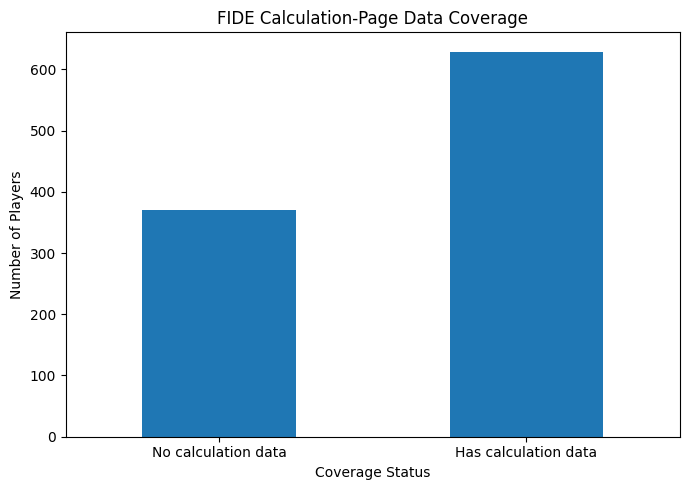

In [40]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

coverage_counts = model_eda_df["has_calculation_data"].value_counts().sort_index()
coverage_counts.index = ["No calculation data", "Has calculation data"]

display(coverage_counts)

plt.figure(figsize=(7, 5))
coverage_counts.plot(kind="bar")
plt.title("FIDE Calculation-Page Data Coverage")
plt.xlabel("Coverage Status")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 2: Rating-band distribution

rating_band
1200-1399      1
1400-1599    862
1600-1799    107
1800-1999     20
2000+         10
Name: count, dtype: int64

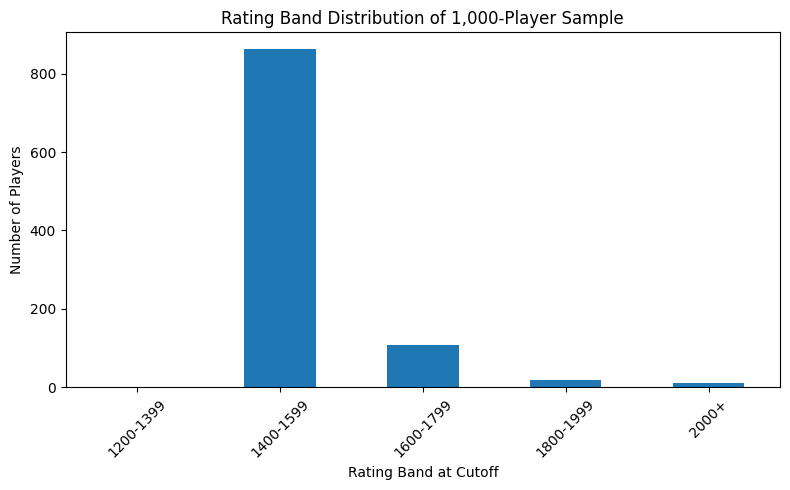

In [42]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

rating_band_counts = (
    model_eda_df["rating_band"]
    .value_counts()
    .sort_index()
)

display(rating_band_counts)

plt.figure(figsize=(8, 5))
rating_band_counts.plot(kind="bar")
plt.title("Rating Band Distribution of 1,000-Player Sample")
plt.xlabel("Rating Band at Cutoff")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

#Chart 3: 12-month rating gain distribution

count    1000.00
mean       10.39
std        61.93
min      -217.00
25%       -10.00
50%         0.00
75%        12.25
max       404.00
Name: rating_gain_12m, dtype: float64

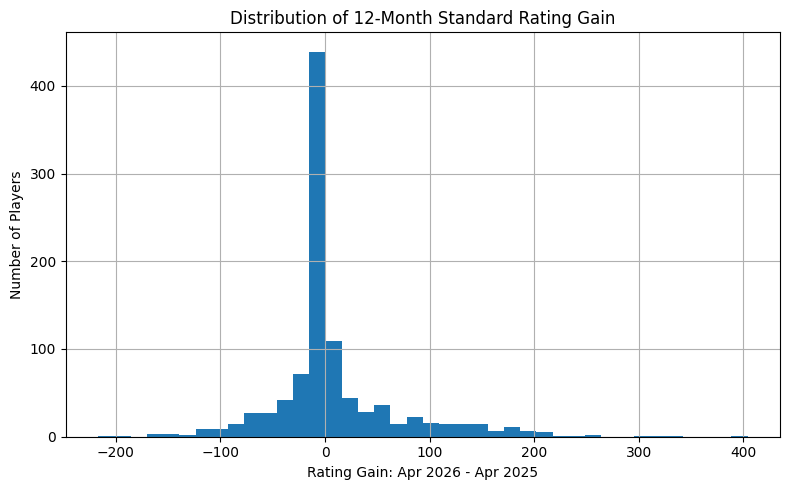

In [44]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

display(model_eda_df[target_col].describe().round(2))

plt.figure(figsize=(8, 5))
model_eda_df[target_col].dropna().hist(bins=40)
plt.title("Distribution of 12-Month Standard Rating Gain")
plt.xlabel("Rating Gain: Apr 2026 - Apr 2025")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 4: Rating at cutoff vs rating gain

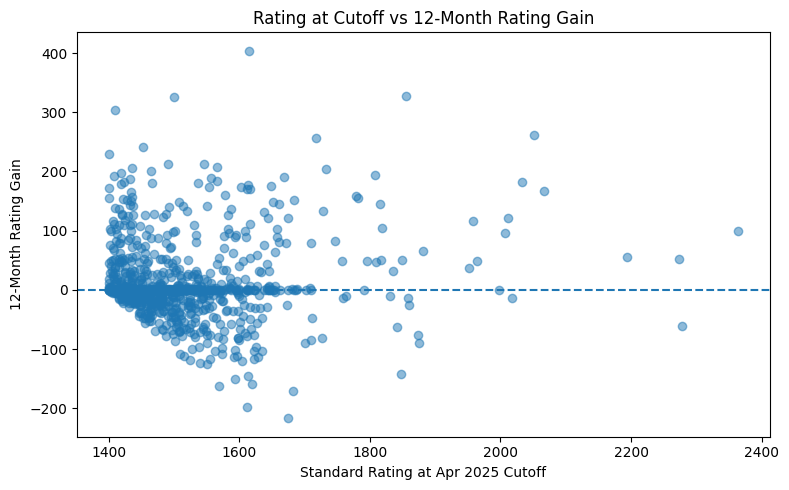

Correlation: 0.069


In [46]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(
    model_eda_df[rating_col],
    model_eda_df[target_col],
    alpha=0.5
)
plt.axhline(0, linestyle="--")
plt.title("Rating at Cutoff vs 12-Month Rating Gain")
plt.xlabel("Standard Rating at Apr 2025 Cutoff")
plt.ylabel("12-Month Rating Gain")
plt.tight_layout()
plt.show()

print("Correlation:", round(model_eda_df[[rating_col, target_col]].corr().iloc[0, 1], 3))

In [47]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 5: Games played vs rating gain

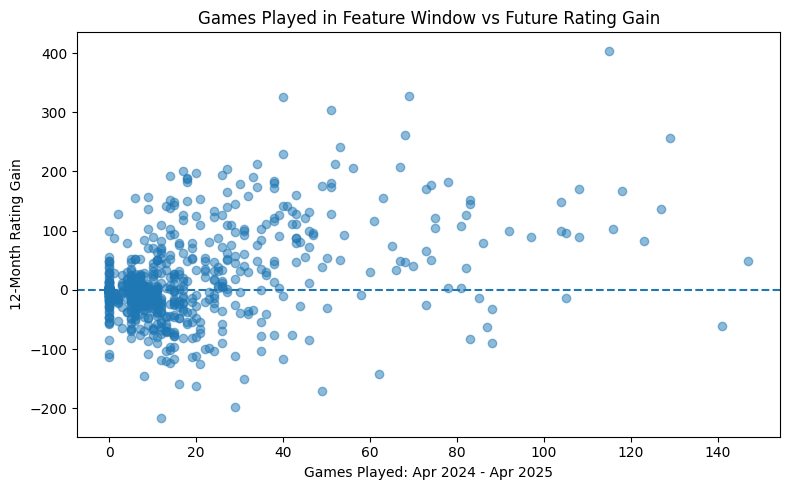

Correlation: 0.419


In [48]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(
    model_eda_df[games_col],
    model_eda_df[target_col],
    alpha=0.5
)
plt.axhline(0, linestyle="--")
plt.title("Games Played in Feature Window vs Future Rating Gain")
plt.xlabel("Games Played: Apr 2024 - Apr 2025")
plt.ylabel("12-Month Rating Gain")
plt.tight_layout()
plt.show()

print("Correlation:", round(model_eda_df[[games_col, target_col]].corr().iloc[0, 1], 3))

In [49]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 6: Active months vs rating gain

,active_months_12m,count,mean,median
0,0,326,-1.37,0.0
1,1,301,-1.04,0.0
2,2,129,0.87,-13.0
3,3,77,12.13,-15.0
4,4,60,43.58,34.5
5,5,32,50.75,55.5
6,6,29,79.69,60.0
7,7,18,62.22,61.5
8,8,10,81.70,87.0
9,9,7,59.29,103.0


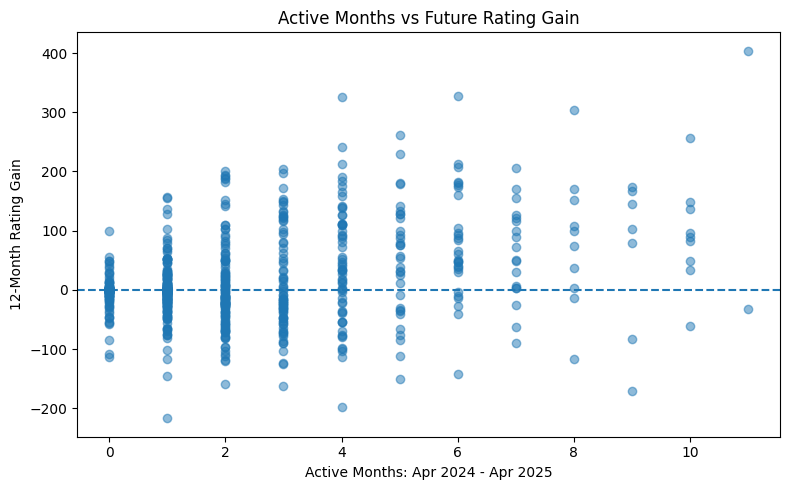

In [50]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

active_col = "active_months_12m"

if active_col in model_eda_df.columns:
    active_summary = (
        model_eda_df
        .groupby(active_col)[target_col]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    display(active_summary.round(2))

    plt.figure(figsize=(8, 5))
    plt.scatter(
        model_eda_df[active_col],
        model_eda_df[target_col],
        alpha=0.5
    )
    plt.axhline(0, linestyle="--")
    plt.title("Active Months vs Future Rating Gain")
    plt.xlabel("Active Months: Apr 2024 - Apr 2025")
    plt.ylabel("12-Month Rating Gain")
    plt.tight_layout()
    plt.show()
else:
    print("Column not found:", active_col)

In [51]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 7: Average opponent rating vs rating gain

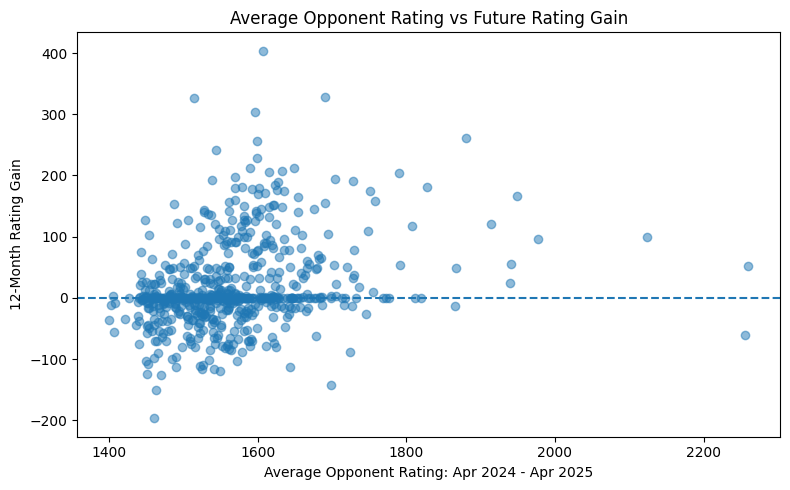

Correlation: 0.282


In [52]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

enriched_df = model_eda_df[model_eda_df["has_calculation_data"] == 1].copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    enriched_df["avg_opponent_rating_12m"],
    enriched_df[target_col],
    alpha=0.5
)
plt.axhline(0, linestyle="--")
plt.title("Average Opponent Rating vs Future Rating Gain")
plt.xlabel("Average Opponent Rating: Apr 2024 - Apr 2025")
plt.ylabel("12-Month Rating Gain")
plt.tight_layout()
plt.show()

print(
    "Correlation:",
    round(enriched_df[["avg_opponent_rating_12m", target_col]].corr().iloc[0, 1], 3)
)

In [53]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 8: Score percentage vs rating gain

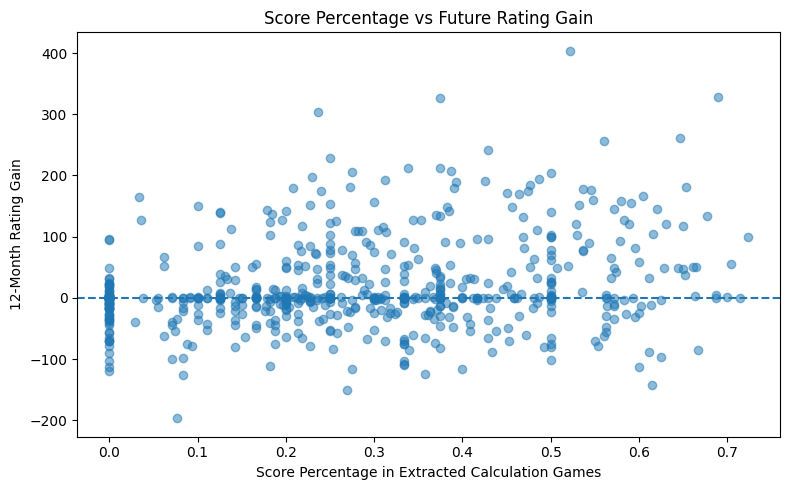

Correlation: 0.244


In [54]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(
    enriched_df["score_percentage_12m"],
    enriched_df[target_col],
    alpha=0.5
)
plt.axhline(0, linestyle="--")
plt.title("Score Percentage vs Future Rating Gain")
plt.xlabel("Score Percentage in Extracted Calculation Games")
plt.ylabel("12-Month Rating Gain")
plt.tight_layout()
plt.show()

print(
    "Correlation:",
    round(enriched_df[["score_percentage_12m", target_col]].corr().iloc[0, 1], 3)
)

In [55]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 9: Average games against 2000+ opponents by rating band

,rating_band,players,avg_games_vs_2000plus,median_games_vs_2000plus
0,1200-1399,1,0.00,0.0
1,1400-1599,520,0.02,0.0
2,1600-1799,79,0.96,0.0
3,1800-1999,19,13.26,12.0
4,2000+,10,93.60,75.0


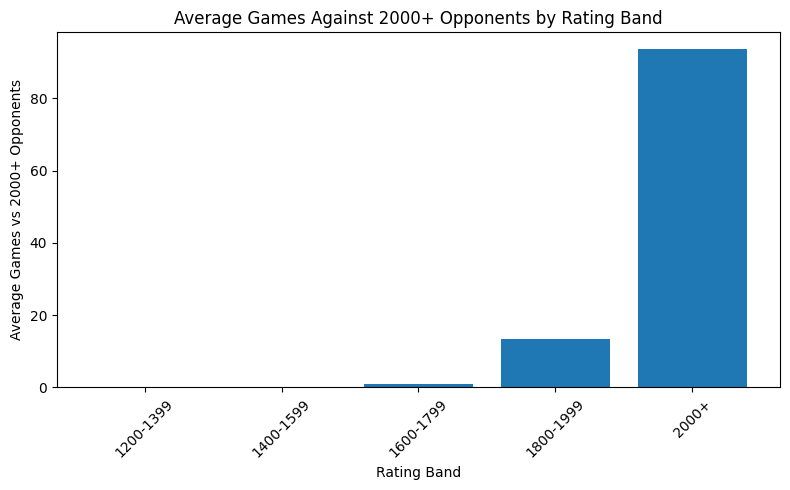

In [56]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

games_2000_summary = (
    enriched_df
    .groupby("rating_band", observed=True)
    .agg(
        players=("ID Number", "count"),
        avg_games_vs_2000plus=("games_vs_2000plus_12m", "mean"),
        median_games_vs_2000plus=("games_vs_2000plus_12m", "median")
    )
    .reset_index()
)

display(games_2000_summary.round(2))

plt.figure(figsize=(8, 5))
plt.bar(
    games_2000_summary["rating_band"].astype(str),
    games_2000_summary["avg_games_vs_2000plus"]
)
plt.title("Average Games Against 2000+ Opponents by Rating Band")
plt.xlabel("Rating Band")
plt.ylabel("Average Games vs 2000+ Opponents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Chart 10: Correlation heatmap

,rating_start,rating_gain_12m,total_games_12m,active_months_12m,inactive_months_12m,calc_games_12m,calc_tournaments_12m,avg_opponent_rating_12m,score_percentage_12m,share_games_vs_higher_rated_12m,total_k_chg_12m
rating_start,1.000,0.069,0.495,0.386,0.031,0.604,0.434,0.631,0.619,-0.505,0.594
rating_gain_12m,0.069,1.000,0.419,0.362,-0.044,0.331,0.301,0.282,0.244,-0.039,0.190
total_games_12m,0.495,0.419,1.000,0.924,-0.286,0.771,0.739,0.367,0.373,-0.281,0.365
active_months_12m,0.386,0.362,0.924,1.000,-0.329,0.659,0.690,0.277,0.282,-0.215,0.254
inactive_months_12m,0.031,-0.044,-0.286,-0.329,1.000,-0.045,-0.078,0.060,0.303,0.076,-0.044
calc_games_12m,0.604,0.331,0.771,0.659,-0.045,1.000,0.926,0.476,0.531,-0.379,0.432
calc_tournaments_12m,0.434,0.301,0.739,0.690,-0.078,0.926,1.000,0.361,0.374,-0.257,0.226
avg_opponent_rating_12m,0.631,0.282,0.367,0.277,0.060,0.476,0.361,1.000,0.270,-0.054,0.425
score_percentage_12m,0.619,0.244,0.373,0.282,0.303,0.531,0.374,0.270,1.000,-0.616,0.436
share_games_vs_higher_rated_12m,-0.505,-0.039,-0.281,-0.215,0.076,-0.379,-0.257,-0.054,-0.616,1.000,-0.159


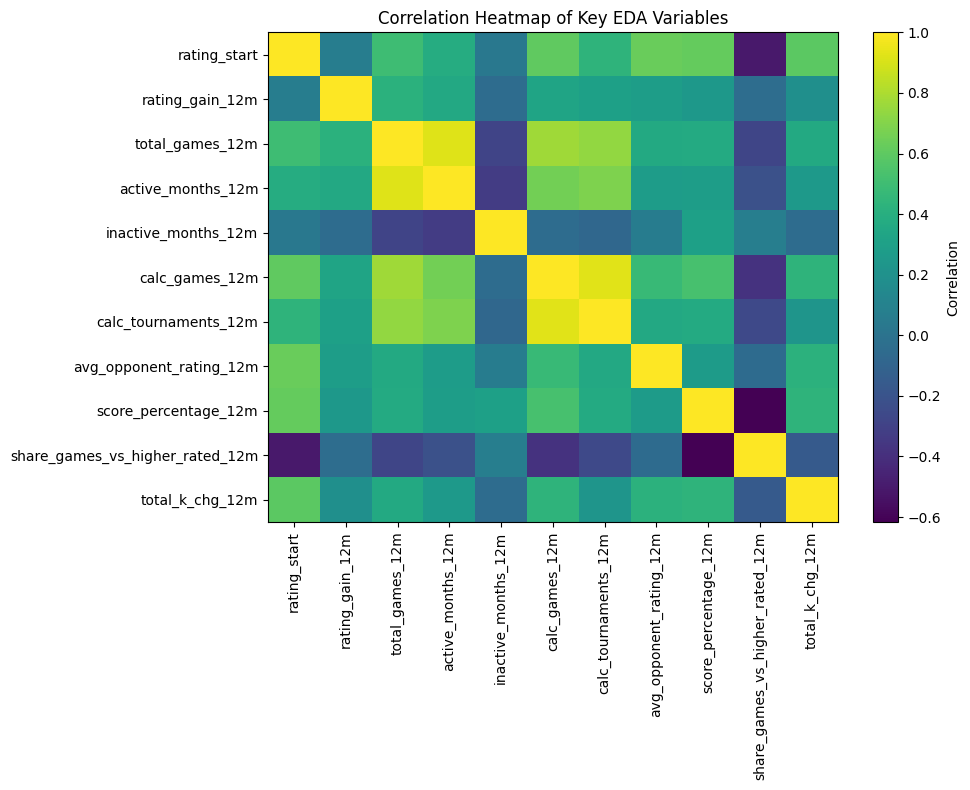

In [58]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

corr_cols = [
    rating_col,
    target_col,
    games_col,
    "active_months_12m",
    "inactive_months_12m",
    "rating_change_3m",
    "rating_change_6m",
    "rating_change_12m",
    "rating_volatility_12m",
    "calc_games_12m",
    "calc_tournaments_12m",
    "avg_opponent_rating_12m",
    "score_percentage_12m",
    "share_games_vs_higher_rated_12m",
    "total_k_chg_12m"
]

corr_cols = [c for c in corr_cols if c in model_eda_df.columns]

corr_matrix = model_eda_df[corr_cols].corr(numeric_only=True)

display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap of Key EDA Variables")
plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Summary tables for report

In [60]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

full_desc_cols = [
    rating_col,
    target_col,
    games_col,
    "active_months_12m",
    "inactive_months_12m",
    "rating_change_3m",
    "rating_change_6m",
    "rating_change_12m",
    "rating_volatility_12m"
]

full_desc_cols = [c for c in full_desc_cols if c in model_eda_df.columns]

full_sample_descriptive = model_eda_df[full_desc_cols].describe().T
display(full_sample_descriptive.round(2))

,count,mean,std,min,25%,50%,75%,max
rating_start,1000.0,1508.35,111.85,1400.0,1435.0,1479.5,1541.00,2364.0
rating_gain_12m,1000.0,10.39,61.93,-217.0,-10.0,0.0,12.25,404.0
total_games_12m,1000.0,13.67,21.16,0.0,0.0,7.0,16.00,147.0
active_months_12m,1000.0,1.74,2.12,0.0,0.0,1.0,2.00,11.0
inactive_months_12m,1000.0,7.27,4.07,0.0,4.0,8.0,11.00,12.0


In [61]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

enriched_desc_cols = [
    "calc_games_12m",
    "calc_tournaments_12m",
    "avg_opponent_rating_12m",
    "max_opponent_rating_12m",
    "avg_event_rc_12m",
    "score_percentage_12m",
    "share_games_vs_higher_rated_12m",
    "games_vs_2000plus_12m",
    "games_vs_2200plus_12m",
    "total_k_chg_12m",
    "avg_game_chg_12m"
]

enriched_desc_cols = [c for c in enriched_desc_cols if c in enriched_df.columns]

enriched_descriptive = enriched_df[enriched_desc_cols].describe().T
display(enriched_descriptive.round(2))

,count,mean,std,min,25%,50%,75%,max
calc_games_12m,629.0,38.48,47.16,2.0,10.00,20.00,44.00,278.00
calc_tournaments_12m,629.0,3.60,3.22,1.0,1.00,2.00,5.00,18.00
avg_opponent_rating_12m,629.0,1565.31,97.53,1400.0,1500.38,1552.50,1608.00,2259.92
max_opponent_rating_12m,629.0,1740.98,193.19,1400.0,1603.00,1718.00,1841.00,2618.00
avg_event_rc_12m,343.0,1619.81,102.44,1401.0,1570.39,1606.77,1648.69,2260.03
score_percentage_12m,629.0,0.28,0.19,0.0,0.14,0.27,0.41,0.72
share_games_vs_higher_rated_12m,343.0,0.73,0.30,0.0,0.50,0.84,1.00,1.00
games_vs_2000plus_12m,629.0,2.02,13.88,0.0,0.00,0.00,0.00,220.00
games_vs_2200plus_12m,629.0,0.89,8.65,0.0,0.00,0.00,0.00,168.00
total_k_chg_12m,629.0,10.96,129.94,-517.6,-22.40,0.00,0.00,723.50


In [62]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

rating_band_gain_summary = (
    model_eda_df
    .groupby("rating_band", observed=True)
    .agg(
        players=("ID Number", "count"),
        mean_gain=(target_col, "mean"),
        median_gain=(target_col, "median"),
        min_gain=(target_col, "min"),
        max_gain=(target_col, "max"),
        mean_games=(games_col, "mean")
    )
    .reset_index()
)

display(rating_band_gain_summary.round(2))

,rating_band,players,mean_gain,median_gain,min_gain,max_gain,mean_games
0,1200-1399,1,0.00,0.0,0,0,0.00
1,1400-1599,862,7.79,0.0,-162,326,10.05
2,1600-1799,107,17.89,0.0,-217,404,29.88
3,1800-1999,20,40.00,42.0,-142,328,50.10
4,2000+,10,96.00,98.0,-61,262,80.90


In [63]:
# ============================================================
# Code cell 53: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

# Save tables:

In [64]:
# ============================================================
#  EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

eda_summary_df = coverage_summary.copy()

eda_summary_df.to_csv(eda_output_dir / "eda_summary.csv", index=False)
full_sample_descriptive.to_csv(eda_output_dir / "full_sample_descriptive.csv")
enriched_descriptive.to_csv(eda_output_dir / "enriched_subset_descriptive.csv")
rating_band_gain_summary.to_csv(eda_output_dir / "rating_band_gain_summary.csv", index=False)

print("Saved EDA outputs to:", eda_output_dir)

Saved EDA outputs to: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures


In [65]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

#base_dir = Path.home() / "Downloads" / "fide_history"
#eda_output_dir = base_dir / "eda_outputs"
#eda_output_dir.mkdir(parents=True, exist_ok=True)

df = model_eda_df.copy()

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (1000, 35)
Columns:
['ID Number', 'Name', 'Fed', 'Sex', 'Title', 'Birth_Year', 'rating_start', 'rating_end', 'months_available', 'total_games_12m', 'avg_monthly_games', 'max_monthly_games', 'active_months_12m', 'inactive_months_12m', 'rating_gain_12m', 'age_approx_2026', 'rating_band', 'fide_id', 'calc_games_12m', 'calc_tournaments_12m', 'avg_opponent_rating_12m', 'max_opponent_rating_12m', 'min_opponent_rating_12m', 'avg_event_rc_12m', 'avg_score_per_game_12m', 'total_score_12m', 'total_k_chg_12m', 'avg_game_chg_12m', 'games_vs_2000plus_12m', 'games_vs_2200plus_12m', 'distinct_event_locations_12m', 'distinct_tournament_countries_12m', 'share_games_vs_higher_rated_12m', 'score_percentage_12m', 'has_calculation_data']


In [66]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

df.columns = df.columns.str.strip()

# Helpful check
for col in df.columns:
    print(col)

ID Number
Name
Fed
Sex
Title
Birth_Year
rating_start
rating_end
months_available
total_games_12m
avg_monthly_games
max_monthly_games
active_months_12m
inactive_months_12m
rating_gain_12m
age_approx_2026
rating_band
fide_id
calc_games_12m
calc_tournaments_12m
avg_opponent_rating_12m
max_opponent_rating_12m
min_opponent_rating_12m
avg_event_rc_12m
avg_score_per_game_12m
total_score_12m
total_k_chg_12m
avg_game_chg_12m
games_vs_2000plus_12m
games_vs_2200plus_12m
distinct_event_locations_12m
distinct_tournament_countries_12m
share_games_vs_higher_rated_12m
score_percentage_12m
has_calculation_data


In [67]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

expected_cols = [
    "fide_id", "ID Number", "player_name", "Name",
    "sex", "Sex",
    "title", "Title", "Tit",
    "age_at_cutoff",
    "rating_start", "rating_cutoff",
    "rating_band",
    "k_factor_cutoff",
    "total_games_12m", "games_12m",
    "active_months_12m",
    "inactive_months_12m",
    "rating_change_3m",
    "rating_change_6m",
    "rating_change_12m",
    "rating_gain_12m", "target_gain_12m",
    "has_calculation_data",
    "calc_games_12m",
    "calc_tournaments_12m",
    "avg_opponent_rating_12m",
    "max_opponent_rating_12m",
    "score_percentage_12m",
    "games_vs_2000plus_12m",
    "games_vs_2200plus_12m",
    "total_k_chg_12m",
    "avg_game_chg_12m"
]

In [68]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

rename_map = {}

if "ID Number" in df.columns and "fide_id" not in df.columns:
    rename_map["ID Number"] = "fide_id"

if "Name" in df.columns and "player_name" not in df.columns:
    rename_map["Name"] = "player_name"

if "Sex" in df.columns and "sex" not in df.columns:
    rename_map["Sex"] = "sex"

if "Tit" in df.columns and "title" not in df.columns:
    rename_map["Tit"] = "title"

if "Title" in df.columns and "title" not in df.columns:
    rename_map["Title"] = "title"

if "rating_cutoff" in df.columns and "rating_start" not in df.columns:
    rename_map["rating_cutoff"] = "rating_start"

if "games_12m" in df.columns and "total_games_12m" not in df.columns:
    rename_map["games_12m"] = "total_games_12m"

if "target_gain_12m" in df.columns and "rating_gain_12m" not in df.columns:
    rename_map["target_gain_12m"] = "rating_gain_12m"

df = df.rename(columns=rename_map)

print("Renamed columns:")
print(rename_map)

Renamed columns:
{'Name': 'player_name', 'Sex': 'sex', 'Title': 'title'}


In [69]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "has_calculation_data" not in df.columns:
    if "calc_games_12m" in df.columns:
        df["has_calculation_data"] = np.where(df["calc_games_12m"].fillna(0) > 0, 1, 0)
    else:
        df["has_calculation_data"] = np.nan

In [70]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

numeric_vars = [
    "age_at_cutoff",
    "rating_start",
    "k_factor_cutoff",
    "rating_change_3m",
    "rating_change_6m",
    "rating_change_12m",
    "total_games_12m",
    "active_months_12m",
    "inactive_months_12m",
    "rating_volatility_12m",
    "calc_games_12m",
    "calc_tournaments_12m",
    "avg_opponent_rating_12m",
    "max_opponent_rating_12m",
    "score_percentage_12m",
    "games_vs_2000plus_12m",
    "games_vs_2200plus_12m",
    "total_k_chg_12m",
    "avg_game_chg_12m",
    "rating_gain_12m"
]

numeric_vars = [c for c in numeric_vars if c in df.columns]

numeric_summary = (
    df[numeric_vars]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .reset_index()
    .rename(columns={
        "index": "variable",
        "count": "non_missing_count",
        "mean": "mean",
        "std": "std",
        "min": "min",
        "25%": "p25",
        "50%": "median",
        "75%": "p75",
        "max": "max"
    })
)

numeric_summary["missing_count"] = len(df) - numeric_summary["non_missing_count"]
numeric_summary["missing_pct"] = (numeric_summary["missing_count"] / len(df) * 100).round(2)

numeric_summary = numeric_summary[
    ["variable", "non_missing_count", "missing_count", "missing_pct",
     "mean", "std", "min", "p25", "median", "p75", "max"]
]

numeric_summary_rounded = numeric_summary.copy()
num_cols = numeric_summary_rounded.select_dtypes(include="number").columns
numeric_summary_rounded[num_cols] = numeric_summary_rounded[num_cols].round(2)

display(numeric_summary_rounded)

,variable,non_missing_count,missing_count,missing_pct,mean,std,min,p25,median,p75,max
0,rating_start,1000.0,0.0,0.0,1508.35,111.85,1400.0,1435.00,1479.50,1541.00,2364.00
1,total_games_12m,1000.0,0.0,0.0,13.67,21.16,0.0,0.00,7.00,16.00,147.00
2,active_months_12m,1000.0,0.0,0.0,1.74,2.12,0.0,0.00,1.00,2.00,11.00
3,inactive_months_12m,1000.0,0.0,0.0,7.27,4.07,0.0,4.00,8.00,11.00,12.00
4,calc_games_12m,1000.0,0.0,0.0,24.20,41.76,0.0,0.00,10.00,26.50,278.00
5,calc_tournaments_12m,1000.0,0.0,0.0,2.26,3.09,0.0,0.00,1.00,3.00,18.00
6,avg_opponent_rating_12m,629.0,371.0,37.1,1565.31,97.53,1400.0,1500.38,1552.50,1608.00,2259.92
7,max_opponent_rating_12m,629.0,371.0,37.1,1740.98,193.19,1400.0,1603.00,1718.00,1841.00,2618.00
8,score_percentage_12m,629.0,371.0,37.1,0.28,0.19,0.0,0.14,0.27,0.41,0.72
9,games_vs_2000plus_12m,1000.0,0.0,0.0,1.27,11.05,0.0,0.00,0.00,0.00,220.00


In [71]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

numeric_summary_path = eda_output_dir / "univariate_numeric_summary.csv"
numeric_summary_rounded.to_csv(numeric_summary_path, index=False)

print("Saved:", numeric_summary_path)

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_numeric_summary.csv


In [72]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

categorical_vars = [
    "sex",
    "title",
    "rating_band",
    "has_calculation_data"
]

categorical_vars = [c for c in categorical_vars if c in df.columns]

cat_summary_parts = []

for col in categorical_vars:
    temp = (
        df[col]
        .fillna("Missing")
        .astype(str)
        .value_counts(dropna=False)
        .reset_index()
    )
    temp.columns = ["category", "count"]
    temp["variable"] = col
    temp["percentage"] = (temp["count"] / len(df) * 100).round(2)
    temp = temp[["variable", "category", "count", "percentage"]]
    cat_summary_parts.append(temp)

categorical_summary = pd.concat(cat_summary_parts, ignore_index=True)

display(categorical_summary)

,variable,category,count,percentage
0,sex,M,822,82.2
1,sex,F,178,17.8
2,title,Missing,989,98.9
3,title,FM,4,0.4
4,title,CM,3,0.3
5,title,WFM,3,0.3
6,title,IM,1,0.1
7,rating_band,1400-1599,862,86.2
8,rating_band,1600-1799,107,10.7
9,rating_band,1800-1999,20,2.0


In [73]:
# ============================================================
# EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

categorical_summary_path = eda_output_dir / "univariate_categorical_summary.csv"
categorical_summary.to_csv(categorical_summary_path, index=False)

print("Saved:", categorical_summary_path)

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_categorical_summary.csv


In [74]:
# ============================================================
# Code cell 64: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

missing_summary = pd.DataFrame({
    "variable": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().sum().values / len(df) * 100).round(2)
})

missing_summary = missing_summary.sort_values("missing_pct", ascending=False)

display(missing_summary.head(30))

,variable,missing_count,missing_pct
4,title,989,98.9
32,share_games_vs_higher_rated_12m,657,65.7
23,avg_event_rc_12m,657,65.7
17,fide_id,371,37.1
26,total_k_chg_12m,371,37.1
20,avg_opponent_rating_12m,371,37.1
21,max_opponent_rating_12m,371,37.1
22,min_opponent_rating_12m,371,37.1
24,avg_score_per_game_12m,371,37.1
25,total_score_12m,371,37.1


In [75]:
# ============================================================
# Code cell 65: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

missing_summary_path = eda_output_dir / "univariate_missing_summary.csv"
missing_summary.to_csv(missing_summary_path, index=False)

print("Saved:", missing_summary_path)

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_missing_summary.csv


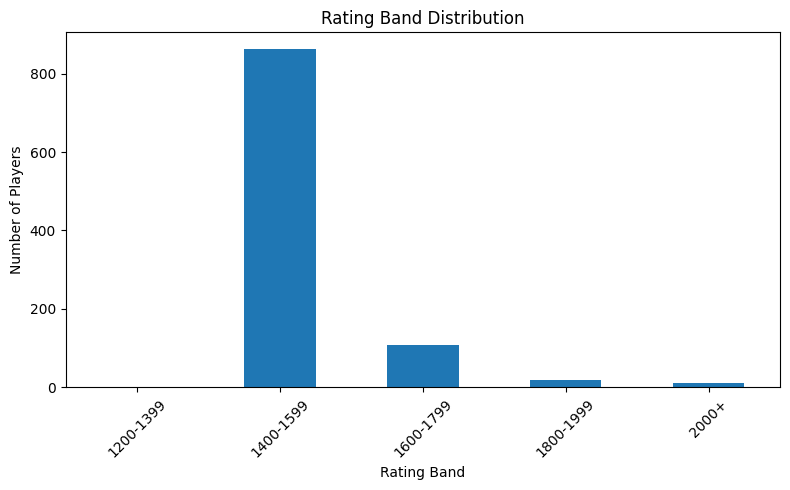

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_rating_band_distribution.png


In [76]:
# ============================================================
# Code cell 66: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "rating_band" in df.columns:
    plt.figure(figsize=(8, 5))
    df["rating_band"].fillna("Missing").astype(str).value_counts().sort_index().plot(kind="bar")
    plt.title("Rating Band Distribution")
    plt.xlabel("Rating Band")
    plt.ylabel("Number of Players")
    plt.xticks(rotation=45)
    plt.tight_layout()
    path = eda_output_dir / "univariate_rating_band_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

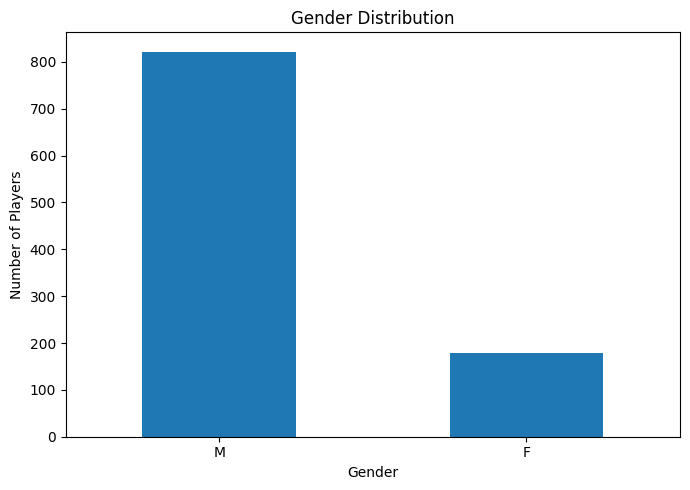

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_gender_distribution.png


In [77]:
# ============================================================
# Code cell 67: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "sex" in df.columns:
    plt.figure(figsize=(7, 5))
    df["sex"].fillna("Missing").astype(str).value_counts().plot(kind="bar")
    plt.title("Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Number of Players")
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = eda_output_dir / "univariate_gender_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

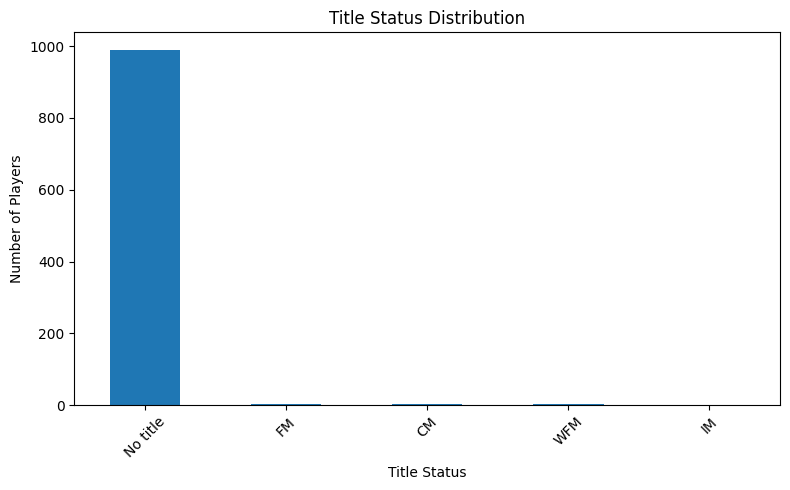

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_title_distribution.png


In [78]:
# ============================================================
# Code cell 68: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "title" in df.columns:
    title_clean = df["title"].replace("", np.nan).fillna("No title").astype(str)

    plt.figure(figsize=(8, 5))
    title_clean.value_counts().plot(kind="bar")
    plt.title("Title Status Distribution")
    plt.xlabel("Title Status")
    plt.ylabel("Number of Players")
    plt.xticks(rotation=45)
    plt.tight_layout()
    path = eda_output_dir / "univariate_title_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

In [79]:
# ============================================================
# Code cell 69: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "age_at_cutoff" in df.columns:
    plt.figure(figsize=(8, 5))
    df["age_at_cutoff"].dropna().plot(kind="hist", bins=10)
    plt.title("Age at Cutoff Distribution")
    plt.xlabel("Age at Apr 2025 Cutoff")
    plt.ylabel("Number of Players")
    plt.tight_layout()
    path = eda_output_dir / "univariate_age_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

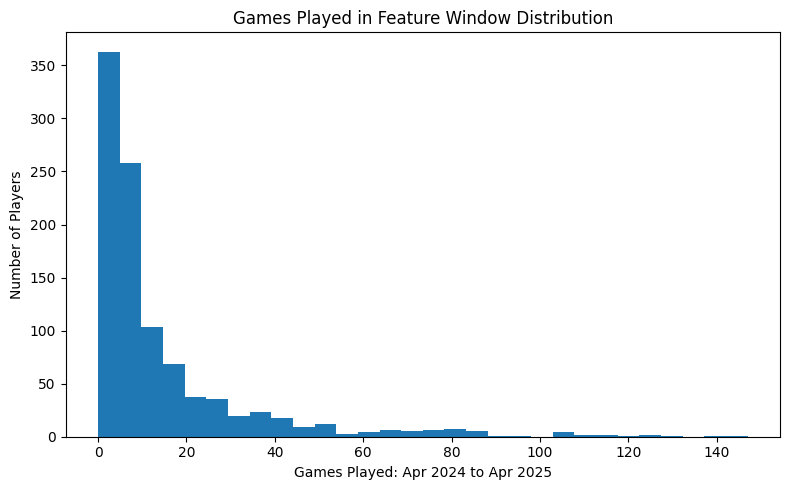

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_games_12m_distribution.png


In [80]:
# ============================================================
# Code cell 70: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "total_games_12m" in df.columns:
    plt.figure(figsize=(8, 5))
    df["total_games_12m"].dropna().plot(kind="hist", bins=30)
    plt.title("Games Played in Feature Window Distribution")
    plt.xlabel("Games Played: Apr 2024 to Apr 2025")
    plt.ylabel("Number of Players")
    plt.tight_layout()
    path = eda_output_dir / "univariate_games_12m_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

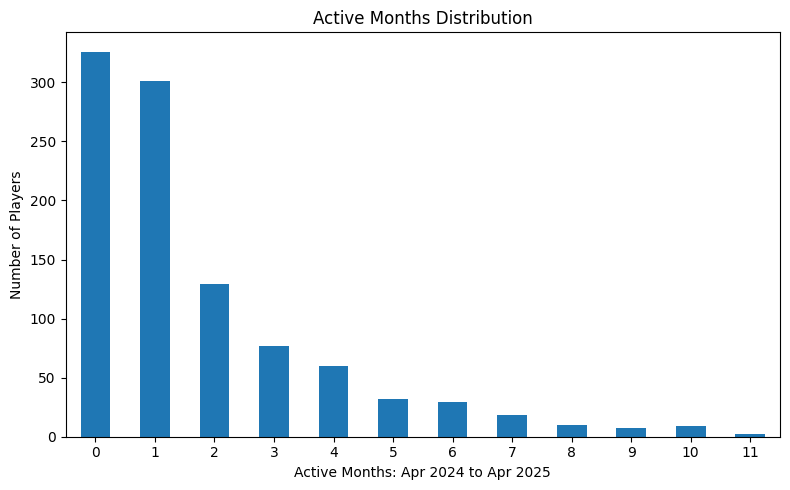

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_active_months_distribution.png


In [81]:
# ============================================================
# Code cell 71: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "active_months_12m" in df.columns:
    plt.figure(figsize=(8, 5))
    df["active_months_12m"].dropna().value_counts().sort_index().plot(kind="bar")
    plt.title("Active Months Distribution")
    plt.xlabel("Active Months: Apr 2024 to Apr 2025")
    plt.ylabel("Number of Players")
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = eda_output_dir / "univariate_active_months_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

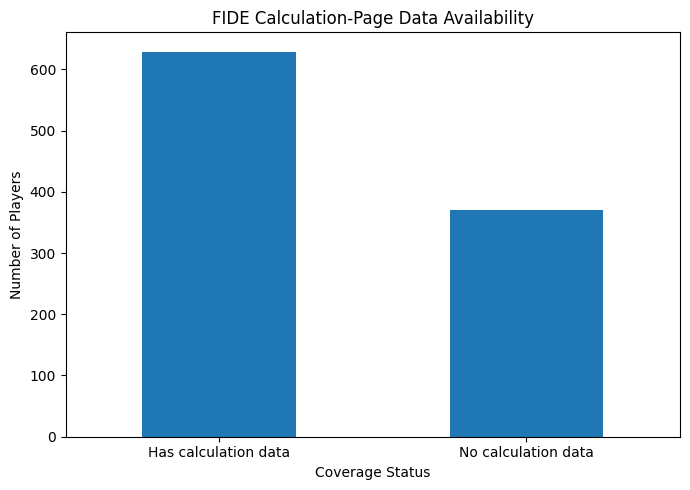

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_calculation_data_availability.png


In [82]:
# ============================================================
# Code cell 72: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "has_calculation_data" in df.columns:
    coverage_labels = df["has_calculation_data"].map({
        0: "No calculation data",
        1: "Has calculation data"
    }).fillna("Missing")

    plt.figure(figsize=(7, 5))
    coverage_labels.value_counts().plot(kind="bar")
    plt.title("FIDE Calculation-Page Data Availability")
    plt.xlabel("Coverage Status")
    plt.ylabel("Number of Players")
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = eda_output_dir / "univariate_calculation_data_availability.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

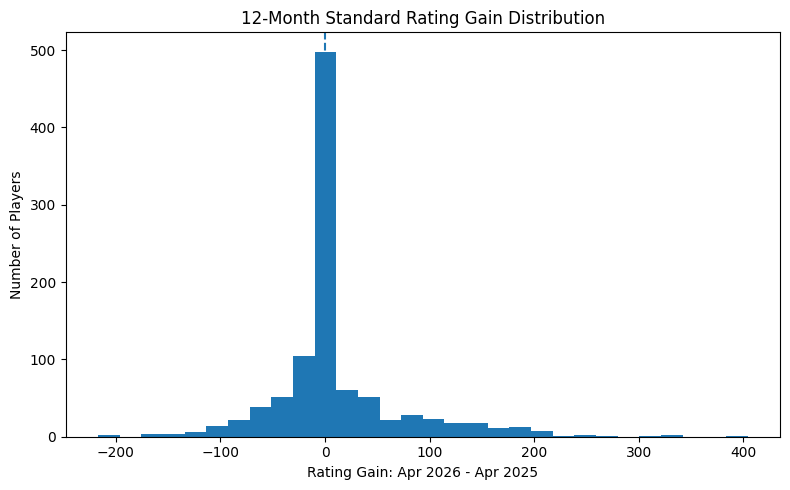

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/univariate_rating_gain_12m_distribution.png


In [83]:
# ============================================================
# Code cell 73: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

if "rating_gain_12m" in df.columns:
    plt.figure(figsize=(8, 5))
    df["rating_gain_12m"].dropna().plot(kind="hist", bins=30)
    plt.axvline(0, linestyle="--")
    plt.title("12-Month Standard Rating Gain Distribution")
    plt.xlabel("Rating Gain: Apr 2026 - Apr 2025")
    plt.ylabel("Number of Players")
    plt.tight_layout()
    path = eda_output_dir / "univariate_rating_gain_12m_distribution.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

In [84]:
# ============================================================
# Code cell 74: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

report_rows = []

def add_numeric_row(var, label):
    if var in df.columns:
        s = pd.to_numeric(df[var], errors="coerce")
        report_rows.append({
            "Variable Group": label,
            "Variable": var,
            "N": s.notna().sum(),
            "Missing %": round(s.isna().mean() * 100, 2),
            "Mean": round(s.mean(), 2),
            "Median": round(s.median(), 2),
            "Min": round(s.min(), 2),
            "Max": round(s.max(), 2)
        })

add_numeric_row("age_at_cutoff", "Player profile")
add_numeric_row("rating_start", "Baseline rating")
add_numeric_row("k_factor_cutoff", "Baseline rating")
add_numeric_row("total_games_12m", "Activity")
add_numeric_row("active_months_12m", "Activity")
add_numeric_row("inactive_months_12m", "Activity")
add_numeric_row("rating_change_3m", "Rating momentum")
add_numeric_row("rating_change_6m", "Rating momentum")
add_numeric_row("rating_change_12m", "Rating momentum")
add_numeric_row("calc_games_12m", "Enrichment")
add_numeric_row("calc_tournaments_12m", "Enrichment")
add_numeric_row("avg_opponent_rating_12m", "Opponent strength")
add_numeric_row("score_percentage_12m", "Performance quality")
add_numeric_row("rating_gain_12m", "Outcome")

report_univariate_numeric = pd.DataFrame(report_rows)

display(report_univariate_numeric)

,Variable Group,Variable,N,Missing %,Mean,Median,Min,Max
0,Baseline rating,rating_start,1000,0.0,1508.35,1479.50,1400.0,2364.00
1,Activity,total_games_12m,1000,0.0,13.67,7.00,0.0,147.00
2,Activity,active_months_12m,1000,0.0,1.74,1.00,0.0,11.00
3,Activity,inactive_months_12m,1000,0.0,7.27,8.00,0.0,12.00
4,Enrichment,calc_games_12m,1000,0.0,24.20,10.00,0.0,278.00
5,Enrichment,calc_tournaments_12m,1000,0.0,2.26,1.00,0.0,18.00
6,Opponent strength,avg_opponent_rating_12m,629,37.1,1565.31,1552.50,1400.0,2259.92
7,Performance quality,score_percentage_12m,629,37.1,0.28,0.27,0.0,0.72
8,Outcome,rating_gain_12m,1000,0.0,10.39,0.00,-217.0,404.00


In [85]:
# ============================================================
# Code cell 75: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

report_univariate_numeric_path = eda_output_dir / "report_univariate_numeric_table.csv"
report_univariate_numeric.to_csv(report_univariate_numeric_path, index=False)

print("Saved:", report_univariate_numeric_path)

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/report_univariate_numeric_table.csv


In [86]:
# ============================================================
# Code cell 76: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

cat_report_rows = []

def add_cat_rows(var, label):
    if var in df.columns:
        counts = df[var].replace("", np.nan).fillna("Missing").astype(str).value_counts()
        for category, count in counts.items():
            cat_report_rows.append({
                "Variable Group": label,
                "Variable": var,
                "Category": category,
                "Count": int(count),
                "Percentage": round(count / len(df) * 100, 2)
            })

add_cat_rows("sex", "Player profile")
add_cat_rows("title", "Player profile")
add_cat_rows("rating_band", "Baseline rating")
add_cat_rows("has_calculation_data", "Enrichment availability")

report_univariate_categorical = pd.DataFrame(cat_report_rows)

display(report_univariate_categorical)

,Variable Group,Variable,Category,Count,Percentage
0,Player profile,sex,M,822,82.2
1,Player profile,sex,F,178,17.8
2,Player profile,title,Missing,989,98.9
3,Player profile,title,FM,4,0.4
4,Player profile,title,CM,3,0.3
5,Player profile,title,WFM,3,0.3
6,Player profile,title,IM,1,0.1
7,Baseline rating,rating_band,1400-1599,862,86.2
8,Baseline rating,rating_band,1600-1799,107,10.7
9,Baseline rating,rating_band,1800-1999,20,2.0


In [87]:
# ============================================================
# Code cell 77: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

report_univariate_categorical_path = eda_output_dir / "report_univariate_categorical_table.csv"
report_univariate_categorical.to_csv(report_univariate_categorical_path, index=False)

print("Saved:", report_univariate_categorical_path)

Saved: /Users/arunkumar/Desktop/Arun/Arun/DBA-Walsh/SecondYr/Capstone/ML_Driven_TalentIdentification_In_Youth_Chess/outputs/figures/report_univariate_categorical_table.csv


In [88]:
# ============================================================
# Code cell 78: EDA / report-figure workflow
# Purpose:
# - This cell supports exploratory analysis, visualization, or report output.
# - Code logic has not been changed; only explanatory comments were added.
# ============================================================

display(report_univariate_numeric)
display(report_univariate_categorical)

,Variable Group,Variable,N,Missing %,Mean,Median,Min,Max
0,Baseline rating,rating_start,1000,0.0,1508.35,1479.50,1400.0,2364.00
1,Activity,total_games_12m,1000,0.0,13.67,7.00,0.0,147.00
2,Activity,active_months_12m,1000,0.0,1.74,1.00,0.0,11.00
3,Activity,inactive_months_12m,1000,0.0,7.27,8.00,0.0,12.00
4,Enrichment,calc_games_12m,1000,0.0,24.20,10.00,0.0,278.00
5,Enrichment,calc_tournaments_12m,1000,0.0,2.26,1.00,0.0,18.00
6,Opponent strength,avg_opponent_rating_12m,629,37.1,1565.31,1552.50,1400.0,2259.92
7,Performance quality,score_percentage_12m,629,37.1,0.28,0.27,0.0,0.72
8,Outcome,rating_gain_12m,1000,0.0,10.39,0.00,-217.0,404.00


,Variable Group,Variable,Category,Count,Percentage
0,Player profile,sex,M,822,82.2
1,Player profile,sex,F,178,17.8
2,Player profile,title,Missing,989,98.9
3,Player profile,title,FM,4,0.4
4,Player profile,title,CM,3,0.3
5,Player profile,title,WFM,3,0.3
6,Player profile,title,IM,1,0.1
7,Baseline rating,rating_band,1400-1599,862,86.2
8,Baseline rating,rating_band,1600-1799,107,10.7
9,Baseline rating,rating_band,1800-1999,20,2.0
